##**Problem based on Logistic Regression**

**Importing Important Libraries**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adv = pd.read_csv('/content/advertising (1).csv') #Importing Dataset

In [3]:
adv.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


**Understanding & Cleaning dataset**

In [4]:
adv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [5]:
adv.shape

(1000, 10)

In [6]:
adv.isnull().sum()

,0
Daily Time Spent on Site,0
Age,0
Area Income,0
Daily Internet Usage,0
Ad Topic Line,0
City,0
Male,0
Country,0
Timestamp,0
Clicked on Ad,0


In [7]:
adv.describe().T

,count,mean,std,min,25%,50%,75%,max
Daily Time Spent on Site,1000.0,65.00020,15.853615,32.60,51.3600,68.215,78.5475,91.43
Age,1000.0,36.00900,8.785562,19.00,29.0000,35.000,42.0000,61.00
Area Income,1000.0,55000.00008,13414.634022,13996.50,47031.8025,57012.300,65470.6350,79484.80
Daily Internet Usage,1000.0,180.00010,43.902339,104.78,138.8300,183.130,218.7925,269.96
Male,1000.0,0.48100,0.499889,0.00,0.0000,0.000,1.0000,1.00
Clicked on Ad,1000.0,0.50000,0.500250,0.00,0.0000,0.500,1.0000,1.00


In [8]:
adv.duplicated().sum()

np.int64(0)

In [9]:
cname = adv[['Age', 'Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage', 'Clicked on Ad']]

In [10]:
cname

,Age,Daily Time Spent on Site,Area Income,Daily Internet Usage,Clicked on Ad
0,35,68.95,61833.90,256.09,0
1,31,80.23,68441.85,193.77,0
2,26,69.47,59785.94,236.50,0
3,29,74.15,54806.18,245.89,0
4,35,68.37,73889.99,225.58,0
...,...,...,...,...,...
995,30,72.97,71384.57,208.58,1
996,45,51.30,67782.17,134.42,1
997,51,51.63,42415.72,120.37,1
998,19,55.55,41920.79,187.95,0


**Outlier Analysis**

In [11]:
import plotly.express as px

In [12]:
cnames = (['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage'])
cnames

['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

In [13]:
for x in cnames:
  fig = px.box(adv[x], title=(f'Boxplot of {x}'))
  fig.show()

In [14]:
outcols = ['Area Income'] #Columns having outliers

In [15]:
for x in outcols:
  q1 = adv[x].quantile(0.25)
  q3 = adv[x].quantile(0.75)
  IQR = q3-q1

  LF = q1-(1.5*IQR)
  UF = q3+(1.5*IQR)

  adv = adv[(adv[x]>=LF) & (adv[x]<=UF)]

In [16]:
for x in cnames:
  fig = px.box(adv[x], title=(f'Boxplot of {x}'))
  fig.show()

**Splitting Dataset**

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = adv[['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage']]
Y = adv['Clicked on Ad']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=5)

In [20]:
x_train.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage
598,83.53,36,67686.16,204.56
472,78.37,24,55015.08,207.27
771,64.38,19,52530.10,180.47
200,66.40,40,77567.85,214.42
197,78.57,36,64045.93,239.32


In [21]:
y_train.head()

,Clicked on Ad
598,0
472,0
771,0
200,0
197,0


In [22]:
x_test.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage
979,70.29,31,56974.51,254.65
282,40.67,35,48913.07,133.18
815,80.96,39,67866.95,225.00
231,46.77,32,31092.93,136.40
60,85.61,27,47708.42,183.43


In [23]:
y_test.head()

,Clicked on Ad
979,0
282,1
815,0
231,1
60,0


**Model Training**

In [24]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(x_test)

In [26]:
y_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1])

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix

print(confusion_matrix(y_test,y_pred)) #Confusion matrix

[[102   3]
 [  5  89]]


In [28]:
print(accuracy_score(y_test,y_pred)) #Evaluation of Accuracy of the model


0.9597989949748744


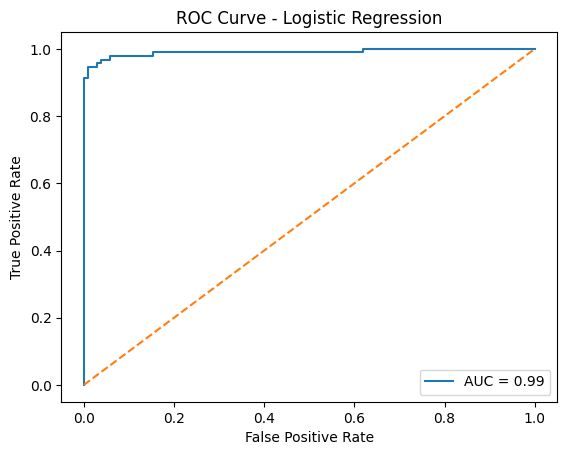

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()
